In [1]:
import warnings
import sys
from pathlib import Path
import pandas as pd
import plotnine as p9
import matplotlib as mpl
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
sys.path.insert(0, str(Path("..").resolve()))
from src.data import prepare_bbg_data
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
p9.theme_set(p9.theme_gray())
mpl.rcParams["figure.edgecolor"] = "none"
mpl.rcParams["savefig.transparent"] = True

START_DATE = "2021-01-01"
END_DATE = "2026-02-20"
DATA_DIR = Path("../data")

eqy = pd.read_excel(DATA_DIR / "equity_indices.xlsx", parse_dates=["Dates"])
eqy = prepare_bbg_data(eqy, START_DATE, END_DATE)

display(eqy.head())

spx = yf.download("^GSPC", start=START_DATE, end=END_DATE)
ftse = yf.download("^FTSE", start=START_DATE, end=END_DATE)

eqy['SPX Index'] = spx['Close']

eqy


,MEXBOL Index,IBOV Index,SPTSX Index,NKY Index,AS51 Index,HSI Index,NIFTY Index,KOSPI Index,STI Index,UKX Index,SMI Index,OMX Index,OSEBX Index,JALSH Index,NZ50SDE Index
date,,,,,,,,,,,,,,,
2022-01-03,52941.01,103921.59,21222.84,28791.71,7444.642,23274.75,17625.70,2988.77,3134.25,7384.54,12939.17,2444.188,1211.32,73722.60,2022.022
2022-01-04,53016.78,103513.64,21236.52,29301.79,7589.757,23289.84,17805.25,2989.24,3181.14,7505.15,12900.97,2456.172,1213.54,75052.06,2022.022
2022-01-05,53024.14,101005.64,21039.66,29332.16,7565.845,22907.25,17925.25,2953.97,3163.44,7516.87,12906.37,2442.811,1221.20,75060.92,2022.022
2022-01-06,53055.31,101561.05,21072.20,28487.87,7358.315,23072.86,17745.90,2920.53,3184.30,7450.37,12792.28,2442.811,1204.44,74165.25,2022.032
2022-01-07,53202.11,102719.47,21084.45,28478.56,7453.347,23493.38,17812.70,2954.89,3205.26,7485.28,12797.94,2400.952,1207.93,73939.71,2022.032


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,MEXBOL Index,IBOV Index,SPTSX Index,NKY Index,AS51 Index,HSI Index,NIFTY Index,KOSPI Index,STI Index,UKX Index,SMI Index,OMX Index,OSEBX Index,JALSH Index,NZ50SDE Index,SPX Index
date,,,,,,,,,,,,,,,,
2022-01-03,52941.01,103921.59,21222.84,28791.71,7444.642,23274.75,17625.70,2988.77,3134.25,7384.54,12939.17,2444.188,1211.32,73722.60,2022.022,4796.560059
2022-01-04,53016.78,103513.64,21236.52,29301.79,7589.757,23289.84,17805.25,2989.24,3181.14,7505.15,12900.97,2456.172,1213.54,75052.06,2022.022,4793.540039
2022-01-05,53024.14,101005.64,21039.66,29332.16,7565.845,22907.25,17925.25,2953.97,3163.44,7516.87,12906.37,2442.811,1221.20,75060.92,2022.022,4700.580078
2022-01-06,53055.31,101561.05,21072.20,28487.87,7358.315,23072.86,17745.90,2920.53,3184.30,7450.37,12792.28,2442.811,1204.44,74165.25,2022.032,4696.049805
2022-01-07,53202.11,102719.47,21084.45,28478.56,7453.347,23493.38,17812.70,2954.89,3205.26,7485.28,12797.94,2400.952,1207.93,73939.71,2022.032,4677.029785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,71478.81,186464.30,33073.71,56941.97,8917.612,26567.12,25471.10,5507.01,4937.78,10446.35,13600.67,3119.757,1822.94,120584.10,2024.070,6836.169922
2026-02-16,71353.29,186464.30,33073.71,56806.41,8937.095,26705.94,25682.75,5507.01,4938.58,10473.69,13656.00,3121.803,1827.51,120988.60,2024.070,NaN
2026-02-17,71155.69,186464.30,32896.55,56566.49,8958.878,26705.94,25725.40,5507.01,4938.58,10556.17,13752.84,3130.122,1820.66,119410.00,2024.070,6843.220215


In [2]:
eqy_returns = eqy.pct_change().fillna(method='ffill')
eqy_returns

,MEXBOL Index,IBOV Index,SPTSX Index,NKY Index,AS51 Index,HSI Index,NIFTY Index,KOSPI Index,STI Index,UKX Index,SMI Index,OMX Index,OSEBX Index,JALSH Index,NZ50SDE Index,SPX Index
date,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,0.001431,-0.003926,0.000645,0.017716,0.019493,0.000648,0.010187,0.000157,0.014961,0.016333,-0.002952,0.004903,0.001833,0.018033,0.000000,-0.000630
2022-01-05,0.000139,-0.024229,-0.009270,0.001036,-0.003151,-0.016427,0.006740,-0.011799,-0.005564,0.001562,0.000419,-0.005440,0.006312,0.000118,0.000000,-0.019393
2022-01-06,0.000588,0.005499,0.001547,-0.028784,-0.027430,0.007230,-0.010005,-0.011320,0.006594,-0.008847,-0.008840,0.000000,-0.013724,-0.011933,0.000005,-0.000964
2022-01-07,0.002767,0.011406,0.000581,-0.000327,0.012915,0.018226,0.003764,0.011765,0.006582,0.004686,0.000442,-0.017136,0.002898,-0.003041,0.000000,-0.004050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,0.008334,-0.006935,0.018741,-0.012107,-0.013925,-0.017217,-0.013023,-0.002763,-0.015743,0.004221,0.005229,-0.001246,-0.008226,-0.013332,0.000000,0.000499
2026-02-16,-0.001756,0.000000,0.000000,-0.002381,0.002185,0.005225,0.008309,0.000000,0.000162,0.002617,0.004068,0.000656,0.002507,0.003355,0.000000,0.000000
2026-02-17,-0.002769,0.000000,-0.005357,-0.004223,0.002437,0.000000,0.001661,0.000000,0.000000,0.007875,0.007091,0.002665,-0.003748,-0.013048,0.000000,0.001031


In [3]:
mex = eqy_returns[['MEXBOL Index', 'SPX Index']]
bra = eqy_returns[['IBOV Index', 'SPX Index']]
saf = eqy_returns[['JALSH Index', 'SPX Index']]
jpn = eqy_returns[['NKY Index', 'SPX Index']]
aus = eqy_returns[['AS51 Index', 'SPX Index']]
can = eqy_returns[['SPTSX Index', 'SPX Index']]
gb = eqy_returns[['UKX Index', 'SPX Index']]
hk = eqy_returns[['HSI Index', 'SPX Index']]
ind = eqy_returns[['NIFTY Index', 'SPX Index']]
kor = eqy_returns[['KOSPI Index', 'SPX Index']]
nrw = eqy_returns[['OSEBX Index', 'SPX Index']]
swd = eqy_returns[['OMX Index', 'SPX Index']]
sng = eqy_returns[['STI Index', 'SPX Index']]
sws = eqy_returns[['SMI Index', 'SPX Index']]
nzw = eqy_returns[['NZ50SDE Index', 'SPX Index']]


countries = {
    'Mexico': mex,
    'Brazil': bra,
    'South Africa': saf,
    'Japan': jpn,
    'Australia': aus,
    'Canada': can,
    'UK': gb,
    'Hong Kong': hk,
    'India': ind,
    'South Korea': kor,
    'Norway': nrw,
    'Sweden': swd,
    'Singapore': sng,
    'Switzerland': sws,
    'New Zealand': nzw
}

In [4]:
for country, data in countries.items():
    data['Excess Return'] = data.iloc[:, 0] - data['SPX Index']
    data['rolling 20 day volatility'] = data['Excess Return'].rolling(window=20).std()
    data['rolling 10 day volatility'] = data['Excess Return'].rolling(window=10).std()
    data['rolling 5 day volatility'] = data['Excess Return'].rolling(window=5).std()
    data['rolling 20 day mean'] = data['Excess Return'].rolling(window=20).mean()
    data['rolling 10 day mean'] = data['Excess Return'].rolling(window=10).mean()
    data['rolling 5 day mean'] = data['Excess Return'].rolling(window=5).mean()
    data['rolling 3 day mean'] = data['Excess Return'].rolling(window=3).mean()
    print(f"{country} - Excess Return and Rolling Statistics:")
    display(data.tail())


Mexico - Excess Return and Rolling Statistics:


,MEXBOL Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.008334,0.000499,0.007835,0.013132,0.013428,0.002888,0.003931,0.007141,0.004676,0.006070
2026-02-16,-0.001756,0.000000,-0.001756,0.013191,0.013096,0.004025,0.003600,0.007505,0.003286,0.003926
2026-02-17,-0.002769,0.001031,-0.003801,0.012383,0.006859,0.005031,0.002219,0.003124,0.002531,0.000759
2026-02-18,-0.003801,0.005566,-0.009367,0.012510,0.006866,0.007049,0.002069,0.003121,-0.000278,-0.004975
2026-02-19,-0.000558,-0.002822,0.002264,0.012490,0.005679,0.006464,0.002227,0.001936,-0.000965,-0.003635


Brazil - Excess Return and Rolling Statistics:


,IBOV Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,-0.006935,0.000499,-0.007434,0.013515,0.014104,0.010679,0.006998,0.004304,0.006658,0.006121
2026-02-16,0.000000,0.000000,0.000000,0.013523,0.014162,0.010259,0.006983,0.004055,0.003999,-0.000654
2026-02-17,0.000000,0.001031,-0.001031,0.012556,0.012306,0.010479,0.005468,0.001535,0.003466,-0.002822
2026-02-18,-0.002403,0.005566,-0.007969,0.012285,0.011199,0.005607,0.003983,0.002367,-0.002192,-0.003000
2026-02-19,0.013537,-0.002822,0.016359,0.012279,0.011429,0.009842,0.003977,0.002547,-0.000015,0.002453


South Africa - Excess Return and Rolling Statistics:


...

,STI Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,-0.015743,0.000499,-0.016242,0.013089,0.015796,0.013633,0.001645,0.002137,0.002935,0.003340
2026-02-16,0.000162,0.000000,0.000162,0.013050,0.015419,0.013656,0.001800,0.002955,0.002835,0.002012
2026-02-17,0.000000,0.001031,-0.001031,0.012398,0.014369,0.013734,0.000788,0.000952,0.001830,-0.005704
2026-02-18,0.000000,0.005566,-0.005566,0.011912,0.014169,0.014009,0.001277,-0.000545,-0.000112,-0.002145
2026-02-19,0.012753,-0.002822,0.015575,0.012305,0.014318,0.011493,0.002138,-0.000421,-0.001421,0.002992


Switzerland - Excess Return and Rolling Statistics:


,SMI Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.005229,0.000499,0.004730,0.009881,0.009515,0.006518,0.001432,0.004548,0.004209,0.007103
2026-02-16,0.004068,0.000000,0.004068,0.009506,0.009210,0.004927,0.002144,0.003819,0.005743,0.007731
2026-02-17,0.007091,0.001031,0.006060,0.009238,0.009219,0.004742,0.001819,0.003857,0.006287,0.004953
2026-02-18,0.003941,0.005566,-0.001625,0.008645,0.008418,0.005763,0.002367,0.002174,0.005526,0.002834
2026-02-19,-0.000540,-0.002822,0.002283,0.008626,0.008060,0.002973,0.002484,0.001488,0.003103,0.002239


New Zealand - Excess Return and Rolling Statistics:


,NZ50SDE Index,SPX Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean
date,,,,,,,,,,
2026-02-13,0.0,0.000499,-0.000499,0.009129,0.010116,0.007750,0.000714,0.001446,0.002765,0.005070
2026-02-16,0.0,0.000000,0.000000,0.009129,0.009851,0.006853,0.000714,0.001986,0.003703,0.005054
2026-02-17,0.0,0.001031,-0.001031,0.007836,0.009617,0.007183,-0.000369,0.001042,0.002836,-0.000510
2026-02-18,0.0,0.005566,-0.005566,0.007490,0.009710,0.008107,-0.000068,-0.000022,0.001713,-0.002199
2026-02-19,0.0,-0.002822,0.002822,0.007404,0.008801,0.003025,0.000347,-0.000965,-0.000855,-0.001258


In [5]:
residuals = pd.read_csv(DATA_DIR / "stage1_residuals.csv").set_index('date')
country_residuals = {}
country_residuals['Australia'] = residuals['AUD']
display(country_residuals['Australia'].tail())
country_residuals['Canada'] = residuals['CAD']
display(country_residuals['Canada'].tail())
country_residuals['Japan'] = residuals['JPY']
country_residuals['Mexico'] = residuals['MXN']
country_residuals['South Africa'] = residuals['ZAR']
country_residuals['UK'] = residuals['GBP']
country_residuals['Brazil'] = residuals['BRL']
country_residuals['Hong Kong'] = residuals['HKD']
country_residuals['India'] = residuals['INR']
country_residuals['South Korea'] = residuals['KRW']
country_residuals['Norway'] = residuals['NOK']
country_residuals['Sweden'] = residuals['SEK']
country_residuals['Singapore'] = residuals['SGD']
country_residuals['Switzerland'] = residuals['CHF']
country_residuals['New Zealand'] = residuals['NZD']

date
2025-12-19    0.006579
2025-12-24    0.004552
2025-12-29   -0.000185
2025-12-30   -0.000997
2025-12-31   -0.004235
Name: AUD, dtype: float64

date
2025-12-19    0.001977
2025-12-24    0.004331
2025-12-29    0.000036
2025-12-30   -0.001218
2025-12-31   -0.002054
Name: CAD, dtype: float64

In [6]:
def evaluate_signal(predictions, y_test, top_pcts=[.2]):
    predictions = pd.Series(predictions, index=y_test.index)
    y_test = pd.Series(y_test)
    directional_accuracy = np.mean(
        np.sign(predictions) == np.sign(y_test)
    )
    print("Overall Directional Accuracy:", directional_accuracy)
    strong_accuracies = []
    threshold = 0
    for top_pct in top_pcts:
        threshold = predictions.abs().quantile(1 - top_pct)
        # print(f"Threshold for top {int(top_pct*100)}% signals: {threshold:.4f}")
        strong_mask = predictions.abs() >= threshold
        strong_directional_accuracy = np.mean(
            np.sign(predictions[strong_mask]) == np.sign(y_test[strong_mask])
        )
        print(f"Top {int(top_pct*100)}% Strongest Signals:")
        print(f"Signal Threshold: {threshold:.4f}")
        print("Directional Accuracy:", strong_directional_accuracy)
        strong_accuracies.append((top_pct, strong_directional_accuracy))
    return {
        "overall_direction": directional_accuracy,
        "strong_direction": strong_directional_accuracy
    }, strong_accuracies, threshold


def ols_regression(X_train, y_train, X_test, y_test):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    train_predictions = lr.predict(X_train)
    _, strong_accuracies_train, train_threshold = evaluate_signal(train_predictions, y_train)
    train_r2 = lr.score(X_train, y_train)
    predictions = lr.predict(X_test)
    df = pd.DataFrame({
        'Actual': y_test,
        'Predicted': predictions
    })
    print(f"R^2 Score: {lr.score(X_test, y_test)}")
    _, strong_accuracies_test, test_threshold = evaluate_signal(predictions, y_test)
    return predictions, lr, df[['Actual']], train_r2, lr.score(X_test, y_test), strong_accuracies_train, strong_accuracies_test, train_threshold, test_threshold


def random_forest_model(X_train, y_train, X_test, y_test):
    rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=4,    
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    print("\nImportance-Based Feature Selection:")
    importances = pd.Series(
        rf.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    top_features = importances.index[:int(len(importances)*.5)]

    X_train_reduced = X_train[top_features]
    X_test_reduced  = X_test[top_features]

    rf_reduced = RandomForestRegressor(
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=15,
        random_state=42,
        n_jobs=-1
    )

    rf_reduced.fit(X_train_reduced, y_train)
    train_predictions = rf_reduced.predict(X_train_reduced)
    train_r2 = rf_reduced.score(X_train_reduced, y_train)
    print("\nTraining Data:")
    print("Train R² (Reduced):", train_r2)
    dic, strong_accuracies_train, train_threshold = evaluate_signal(train_predictions, y_train)
    print()
    print("\nTesting Data:")
    predictions_reduced = rf_reduced.predict(X_test_reduced)
    test_r2 = rf_reduced.score(X_test_reduced, y_test)
    print("Reduced Test R²:", test_r2)
    dic, strong_accuracies_test, test_threshold = evaluate_signal(predictions_reduced, y_test)

    return predictions_reduced, train_predictions, rf_reduced, y_test, y_train, train_r2, test_r2, strong_accuracies_train, strong_accuracies_test, train_threshold, test_threshold


# OLS


Running regression for Mexico...


,MEXBOL Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean,MXN
date,,,,,,,,,,
2022-01-31,0.013205,-0.005681,0.010127,0.010776,0.013281,0.001443,-0.001856,-0.003080,-0.010651,-0.002938
2022-02-01,0.008802,0.001939,0.010127,0.010627,0.008812,0.001437,-0.002128,-0.005967,-0.008070,0.001035
2022-02-02,0.004869,-0.004554,0.009256,0.010545,0.008222,0.000233,-0.002784,-0.006913,-0.002765,0.005645
2022-02-03,-0.017098,0.007293,0.009388,0.010750,0.010448,0.000520,-0.002563,-0.004294,0.001560,0.002311
2022-02-04,0.002155,-0.003002,0.009297,0.010650,0.005380,0.000029,-0.003023,-0.000801,-0.000088,0.000499


date
2025-01-03    0.011290
2025-01-06   -0.002328
2025-01-07    0.002820
2025-01-08   -0.004202
2025-01-09   -0.005824
Name: MXN, dtype: float64

Overall Directional Accuracy: 0.49575551782682514
Top 20% Strongest Signals:
Signal Threshold: 0.0004
Directional Accuracy: 0.5084745762711864
R^2 Score: -0.01807351061539242
Overall Directional Accuracy: 0.4976958525345622
Top 20% Strongest Signals:
Signal Threshold: 0.0004
Directional Accuracy: 0.45454545454545453

Running regression for Brazil...


,IBOV Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean,BRL
date,,,,,,,,,,
2022-01-31,0.002086,-0.016800,0.015674,0.020738,0.025995,0.006826,0.008443,0.002881,-0.010037,-0.006163
2022-02-01,0.009673,0.002810,0.015525,0.020295,0.020007,0.007131,0.006609,-0.003191,-0.014856,0.003031
2022-02-02,-0.011781,-0.021204,0.016584,0.021200,0.019380,0.006313,0.002258,-0.009701,-0.011731,-0.000048
2022-02-03,-0.001773,0.022618,0.016981,0.021353,0.021295,0.007121,0.002408,-0.008631,0.001408,0.008611
2022-02-04,0.004915,-0.000242,0.016938,0.020692,0.017454,0.006336,0.000640,-0.002564,0.000391,0.002694


...

date
2025-01-03   -0.001391
2025-01-06   -0.000293
2025-01-07   -0.001793
2025-01-08   -0.002981
2025-01-09   -0.000814
Name: CHF, dtype: float64

Overall Directional Accuracy: 0.5042444821731749
Top 20% Strongest Signals:
Signal Threshold: 0.0001
Directional Accuracy: 0.5338983050847458
R^2 Score: 0.004471199066216736
Overall Directional Accuracy: 0.5345622119815668
Top 20% Strongest Signals:
Signal Threshold: 0.0001
Directional Accuracy: 0.5909090909090909

Running regression for New Zealand...


,NZ50SDE Index,Excess Return,rolling 20 day volatility,rolling 10 day volatility,rolling 5 day volatility,rolling 20 day mean,rolling 10 day mean,rolling 5 day mean,rolling 3 day mean,NZD
date,,,,,,,,,,
2022-01-31,3.461845e-06,-0.018882,0.011619,0.014725,0.015905,0.002951,0.003109,-0.004835,-0.012615,0.000041
2022-02-01,0.000000e+00,-0.006863,0.011817,0.013959,0.012789,0.002576,0.000583,-0.008642,-0.016698,0.003487
2022-02-02,9.890952e-08,-0.009422,0.011409,0.013881,0.011492,0.001135,-0.001328,-0.010826,-0.011723,0.009778
2022-02-03,5.835661e-06,0.024397,0.012537,0.015724,0.018933,0.002307,0.000008,-0.007024,0.002704,0.001762
2022-02-04,0.000000e+00,-0.005157,0.012639,0.014285,0.016306,0.001846,-0.002399,-0.003186,0.003273,-0.000169


date
2025-01-03    0.000636
2025-01-06   -0.000152
2025-01-07    0.000288
2025-01-08   -0.000012
2025-01-09   -0.002767
Name: NZD, dtype: float64

Overall Directional Accuracy: 0.5365025466893039
Top 20% Strongest Signals:
Signal Threshold: 0.0011
Directional Accuracy: 0.652542372881356
R^2 Score: 0.0371952440428428
Overall Directional Accuracy: 0.5023041474654378
Top 20% Strongest Signals:
Signal Threshold: 0.0008
Directional Accuracy: 0.5227272727272727


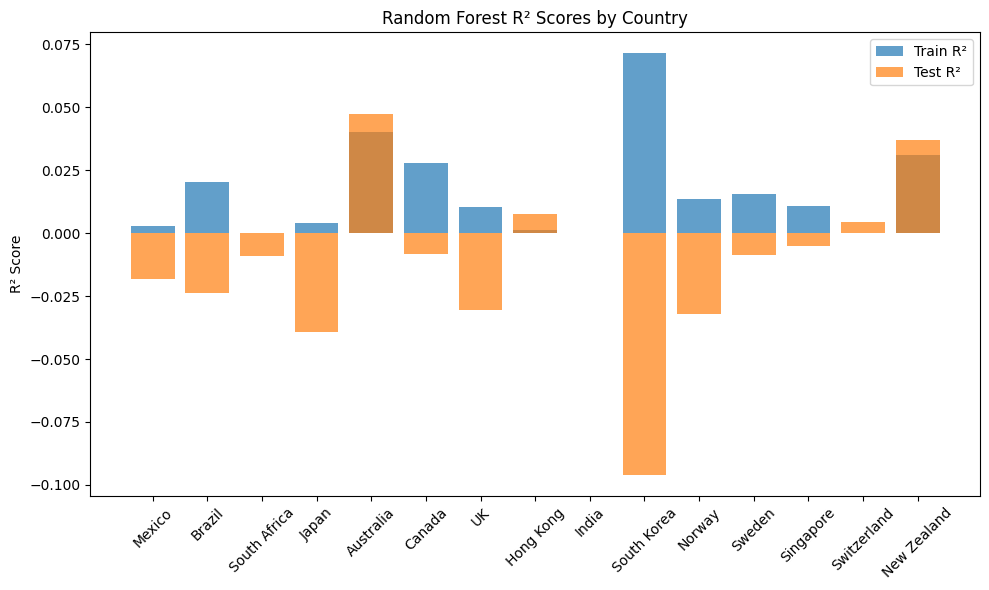

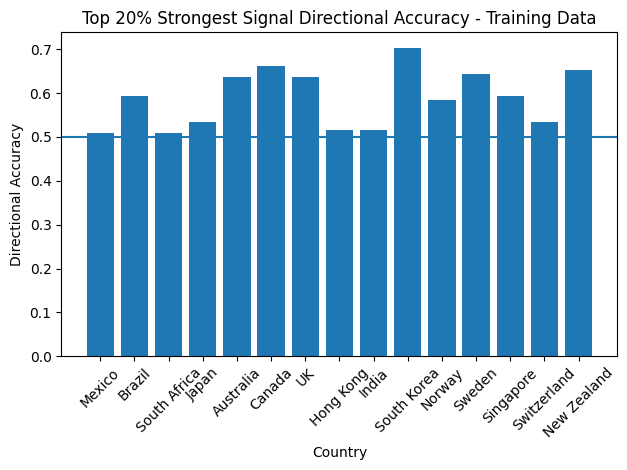

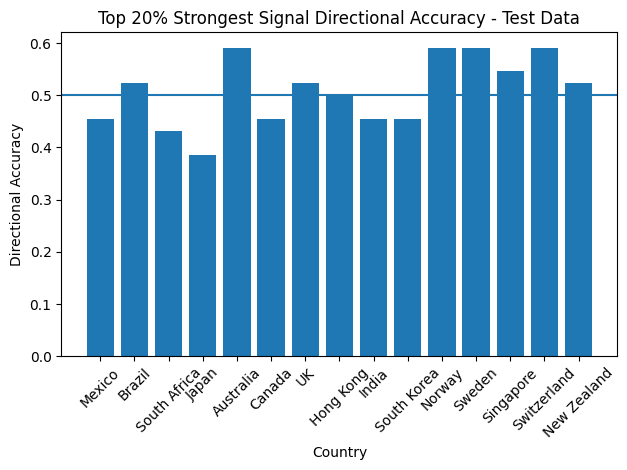

In [7]:

train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}
train_thresholds = {}
test_thresholds = {}

for country, data in countries.items():
    if country not in country_residuals:
        print(f"Residuals for {country} not found. Skipping regression.")
        continue
    print(f"\nRunning regression for {country}...")
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    display(df_train.head())

    X_test = countries[country]['2025-01-01':'2026-01-01']
 
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    display(y_test.head())
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()

    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    model_preds, model, ys, trains_r2, test_r2, strong_acc_train, strong_acc_test, train_threshold, test_threshold = ols_regression(df_train[['Excess Return']], df_train.iloc[:, -1], df_test[['Excess Return']], df_test.iloc[:, -1])
    train_r2s[country] = trains_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test
    train_thresholds[country] = train_threshold
    test_thresholds[country] = test_threshold


plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()

countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 20% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()


Random Forest Regression Results for Mexico:

Importance-Based Feature Selection:

Training Data:
Train R² (Reduced): 0.09923473248600945
Overall Directional Accuracy: 0.5942275042444821
Top 20% Strongest Signals:
Signal Threshold: 0.0014
Directional Accuracy: 0.7203389830508474


Testing Data:
Reduced Test R²: -0.045911674323633855
Overall Directional Accuracy: 0.5161290322580645
Top 20% Strongest Signals:
Signal Threshold: 0.0014
Directional Accuracy: 0.5454545454545454

Random Forest Regression Results for Brazil:

Importance-Based Feature Selection:

Training Data:
Train R² (Reduced): 0.1410457023098589
Overall Directional Accuracy: 0.6129032258064516
Top 20% Strongest Signals:
Signal Threshold: 0.0024
Directional Accuracy: 0.7711864406779662


Testing Data:
Reduced Test R²: -0.041096898070606125
Overall Directional Accuracy: 0.47465437788018433
Top 20% Strongest Signals:
Signal Threshold: 0.0014
Directional Accuracy: 0.5454545454545454

Random Forest Regression Results for South 

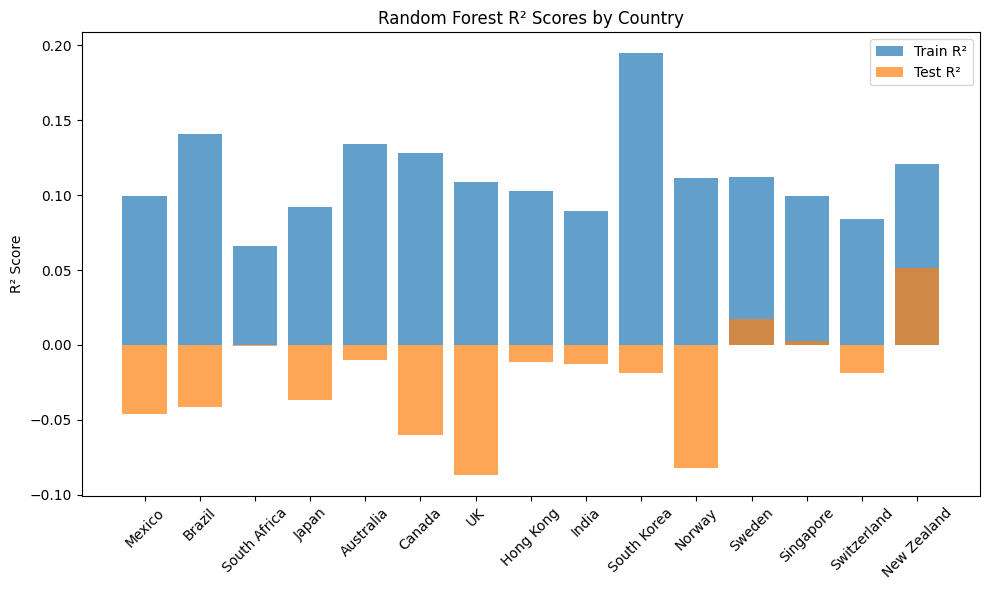

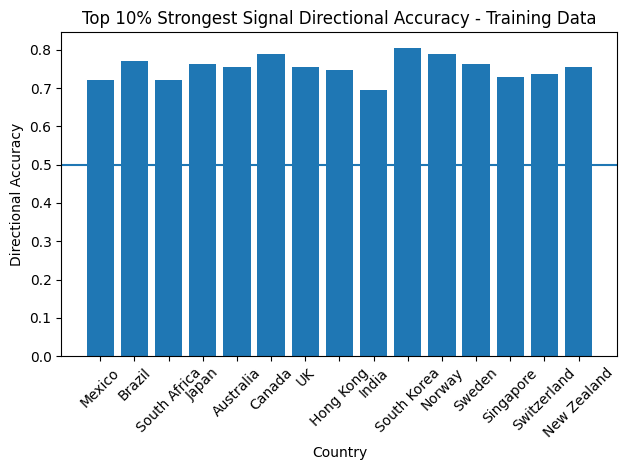

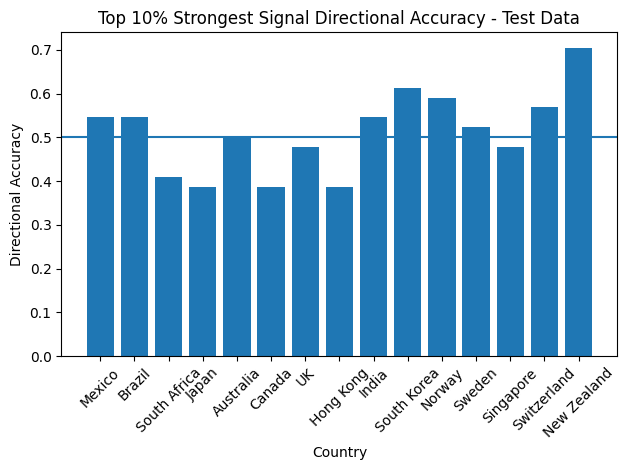

In [8]:
train_r2s = {}
test_r2s = {}
train_accuracies = {}
test_accuracies = {}
train_thresholds = {}
test_thresholds = {}
test_preds = pd.DataFrame()
train_preds = pd.DataFrame()

for country, data in countries.items():
    if country not in country_residuals:
        print(f"\nResiduals for {country} not found. Skipping regression.")
        continue
    X_train = countries[country]['2022-01-01':'2024-09-30']
    y_train = country_residuals[country]['2022-01-01':'2024-09-30'].shift(-1).dropna()  # Shift to align with next day's return
    X_train = X_train.copy()
    y_train = y_train.copy()
    X_train.index = pd.to_datetime(X_train.index)
    y_train.index = pd.to_datetime(y_train.index)
    df_train = pd.concat([X_train, y_train], axis=1).dropna()
    df_train.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features
    
    X_test = countries[country]['2025-01-01':'2026-01-01']
    y_test = country_residuals[country]['2025-01-01':'2026-01-01'].shift(-1).dropna()  # Shift to align with next day's return
    X_test = X_test.copy()
    y_test = y_test.copy()
    X_test.index = pd.to_datetime(X_test.index)
    y_test.index = pd.to_datetime(y_test.index)
    df_test = pd.concat([X_test, y_test], axis=1).dropna()
    df_test.drop(columns=['SPX Index'], inplace=True)  # Drop SPX Index from features

    print(f"\nRandom Forest Regression Results for {country}:")
    rf_test_predictions, rf_train_predictions, rf_model_instance ,y_test, y_train, train_r2, test_r2, strong_acc_train, strong_acc_test, train_threshold, test_threshold = random_forest_model(df_train.iloc[:, :-1], df_train.iloc[:, -1], df_test.iloc[:, :-1], df_test.iloc[:, -1])
    if country == 'Mexico':
        test_preds.index = y_test.index
        train_preds.index = y_train.index
    test_preds[country] = rf_test_predictions
    train_preds[country] = rf_train_predictions
    train_r2s[country] = train_r2
    test_r2s[country] = test_r2
    train_accuracies[country] = strong_acc_train
    test_accuracies[country] = strong_acc_test
    train_thresholds[country] = train_threshold
    test_thresholds[country] = test_threshold



plt.figure(figsize=(10, 6))
plt.bar(train_r2s.keys(), train_r2s.values(), alpha=0.7, label='Train R²')
plt.bar(test_r2s.keys(), test_r2s.values(), alpha=0.7, label='Test R²')
plt.ylabel('R² Score')
plt.title('Random Forest R² Scores by Country')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()


countries2 = list(train_accuracies.keys())
values = [v[0][1] for v in train_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 10% Strongest Signal Directional Accuracy - Training Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()

countries2 = list(test_accuracies.keys())
values = [v[0][1] for v in test_accuracies.values()]
plt.figure()
plt.bar(countries2, values)
plt.xlabel("Country")
plt.ylabel("Directional Accuracy")
plt.title("Top 10% Strongest Signal Directional Accuracy - Test Data")
plt.xticks(rotation=45)
plt.axhline(0.5)
plt.tight_layout()
plt.show()
    

In [9]:
test_preds.mean()

Mexico         -0.000049
Brazil         -0.000037
South Africa   -0.000194
Japan          -0.000159
Australia      -0.000029
Canada         -0.000108
UK             -0.000047
Hong Kong      -0.000017
India          -0.000018
South Korea     0.000599
Norway          0.000251
Sweden          0.000163
Singapore       0.000045
Switzerland    -0.000119
New Zealand    -0.000169
dtype: float64

In [10]:
train_preds.mean()

Mexico         -0.000067
Brazil         -0.000035
South Africa   -0.000173
Japan          -0.000110
Australia       0.000014
Canada         -0.000046
UK             -0.000086
Hong Kong      -0.000001
India          -0.000004
South Korea     0.000009
Norway          0.000212
Sweden          0.000213
Singapore      -0.000011
Switzerland    -0.000029
New Zealand     0.000054
dtype: float64

In [11]:
for country in train_thresholds.keys():
    print(f"{country} - Train Threshold: {train_thresholds[country]:.4f}, Test Threshold: {test_thresholds[country]:.4f}")
    

Mexico - Train Threshold: 0.0014, Test Threshold: 0.0014
Brazil - Train Threshold: 0.0024, Test Threshold: 0.0014
South Africa - Train Threshold: 0.0009, Test Threshold: 0.0007
Japan - Train Threshold: 0.0011, Test Threshold: 0.0010
Australia - Train Threshold: 0.0015, Test Threshold: 0.0013
Canada - Train Threshold: 0.0009, Test Threshold: 0.0006
UK - Train Threshold: 0.0009, Test Threshold: 0.0009
Hong Kong - Train Threshold: 0.0001, Test Threshold: 0.0001
India - Train Threshold: 0.0002, Test Threshold: 0.0002
South Korea - Train Threshold: 0.0024, Test Threshold: 0.0027
Norway - Train Threshold: 0.0018, Test Threshold: 0.0015
Sweden - Train Threshold: 0.0013, Test Threshold: 0.0010
Singapore - Train Threshold: 0.0004, Test Threshold: 0.0004
Switzerland - Train Threshold: 0.0009, Test Threshold: 0.0013
New Zealand - Train Threshold: 0.0011, Test Threshold: 0.0009


In [12]:
test_preds.to_csv("../data/rf_signals.csv")
train_preds.to_csv("../data/rf_train_predictions.csv")

In [13]:
thresholds = pd.DataFrame({
    'Country': list(train_thresholds.keys()),
    'Train Threshold': list(train_thresholds.values()),
    'Test Threshold': list(test_thresholds.values())
})

In [14]:
thresholds.to_csv("../data/rf_exit_thresholds.csv")